In [1]:
import sys
sys.path.append("src")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [2]:
# Common settings

shots = 1024

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

label_map = {
    "no_error": "No Error",
    "E1_before_H": r"$\mathcal{E}_1$ before first $H$",
    "E2_after_first_H": r"$\mathcal{E}_2$ after first $H$",
    "E3_after_oracle": r"$\mathcal{E}_3$ after oracle",
    "E4_after_final_H": r"$\mathcal{E}_4$ after final $H$",
}

def get_success_probability(function_name, P0):
    if function_name in ["constant_0", "constant_1"]:
        return P0
    if function_name == "balanced_parity":
        return 1 - P0
    raise ValueError(f"Unknown function: {function_name}")

def standard_error(p, shots):
    return np.sqrt(p * (1 - p) / shots)

In [3]:
# Experiment 1: Function and axis analysis


n_values_exp1 = [1, 3, 5, 7, 9]
theta_values_exp1 = np.radians(np.arange(0, 181, 10))

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced_parity": qa.deutsch_jozsa.f_balanced_parity,
}

results_exp1 = []

for n in n_values_exp1:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)
        samples_ref = qa.deutsch_jozsa.sample_measurements_input(
            state_ref, n, shots
        )

        P0_ref = samples_ref[0] / shots
        success_ref = get_success_probability(function_name, P0_ref)

        for theta in theta_values_exp1:
            theta_deg = np.degrees(theta)

            for axis_name, axis in axes.items():

                results_exp1.append({
                    "n": n,
                    "theta_rad": theta,
                    "theta_deg": theta_deg,
                    "axis": axis_name,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": "no_error",
                    "P0": P0_ref,
                    "success_probability": success_ref,
                    "std_error": standard_error(success_ref, shots),
                    "shots": shots,
                })

                for error_name, error_function in error_positions.items():

                    state_error = error_function(
                        n, f, theta, target_qubit, axis
                    )

                    samples_error = qa.deutsch_jozsa.sample_measurements_input(
                        state_error, n, shots
                    )

                    P0_error = samples_error[0] / shots
                    success_error = get_success_probability(
                        function_name, P0_error
                    )

                    results_exp1.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": theta_deg,
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "function": function_name,
                        "error_position": error_name,
                        "P0": P0_error,
                        "success_probability": success_error,
                        "std_error": standard_error(success_error, shots),
                        "shots": shots,
                    })

df_functions = pd.DataFrame(results_exp1)
print("Experiment 1 shape:", df_functions.shape)

df_functions.to_csv("experiment1_function_axis_analysis.csv", index=False)
df_functions.head()

Running n = 1
Running n = 3
Running n = 5
Running n = 7
Running n = 9
Experiment 1 shape: (4275, 11)


,n,theta_rad,theta_deg,axis,target_qubit,function,error_position,P0,success_probability,std_error,shots
0,1,0.0,0.0,X,0,constant_1,no_error,1.0,1.0,0.0,1024
1,1,0.0,0.0,X,0,constant_1,E1_before_H,1.0,1.0,0.0,1024
2,1,0.0,0.0,X,0,constant_1,E2_after_first_H,1.0,1.0,0.0,1024
3,1,0.0,0.0,X,0,constant_1,E3_after_oracle,1.0,1.0,0.0,1024
4,1,0.0,0.0,X,0,constant_1,E4_after_final_H,1.0,1.0,0.0,1024


In [4]:
def plot_error_positions(df, n_plot, axis_plot, function_plot):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["axis"] == axis_plot) &
        (df["function"] == function_plot)
    ]

    if plot_df.empty:
        print(
            f"No data found for n={n_plot}, "
            f"axis={axis_plot}, function={function_plot}"
        )
        return

    plt.figure(figsize=(9, 6))

    for error_pos in [
        "no_error",
        "E1_before_H",
        "E2_after_first_H",
        "E3_after_oracle",
        "E4_after_final_H",
    ]:
        subset = plot_df[plot_df["error_position"] == error_pos]

        plt.plot(
            subset["theta_deg"],
            subset["success_probability"],
            linewidth=2,
            label=label_map[error_pos]
        )

    plt.xlabel(r"Rotation angle $\theta$ (degrees)")
    plt.ylabel("Success probability")
    plt.title(
        f"success under rotation errors\n"
        f"function={function_plot}, n={n_plot}, axis={axis_plot}, shots={shots}"
    )

    plt.xlim(0, 180)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Error position")
    plt.tight_layout()

    filename = f"exp1_{function_plot}_n{n_plot}_{axis_plot}.pdf"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()
    print(f"Saved figure: {filename}")

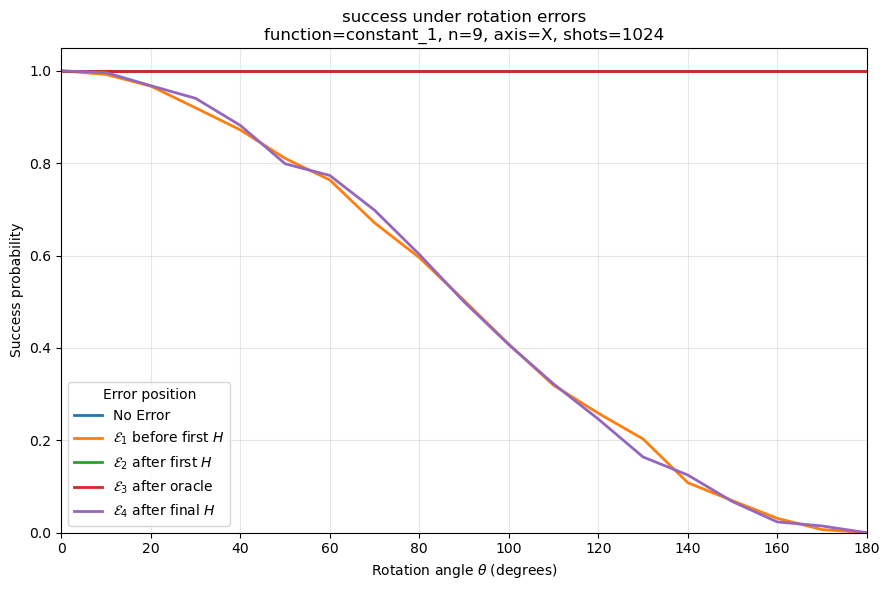

Saved figure: exp1_constant_1_n9_X.pdf


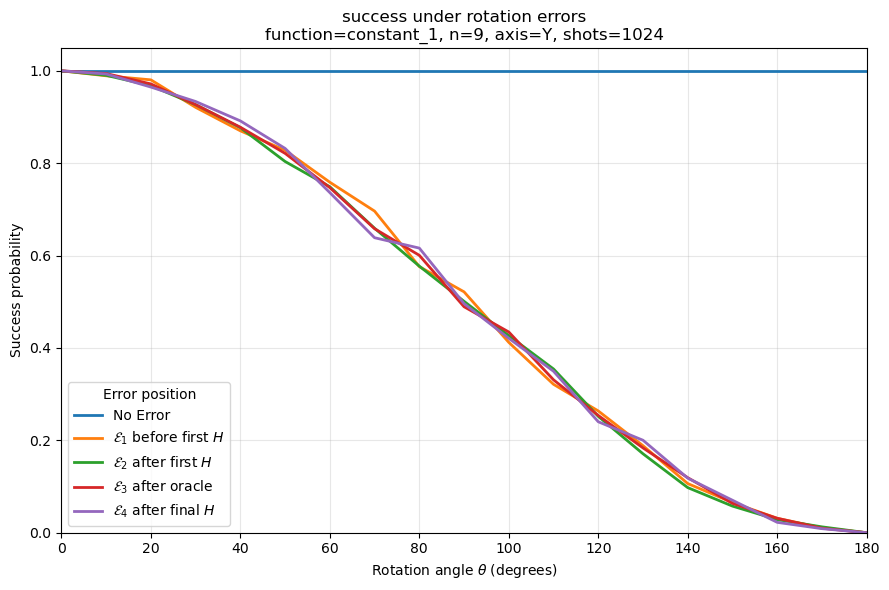

Saved figure: exp1_constant_1_n9_Y.pdf


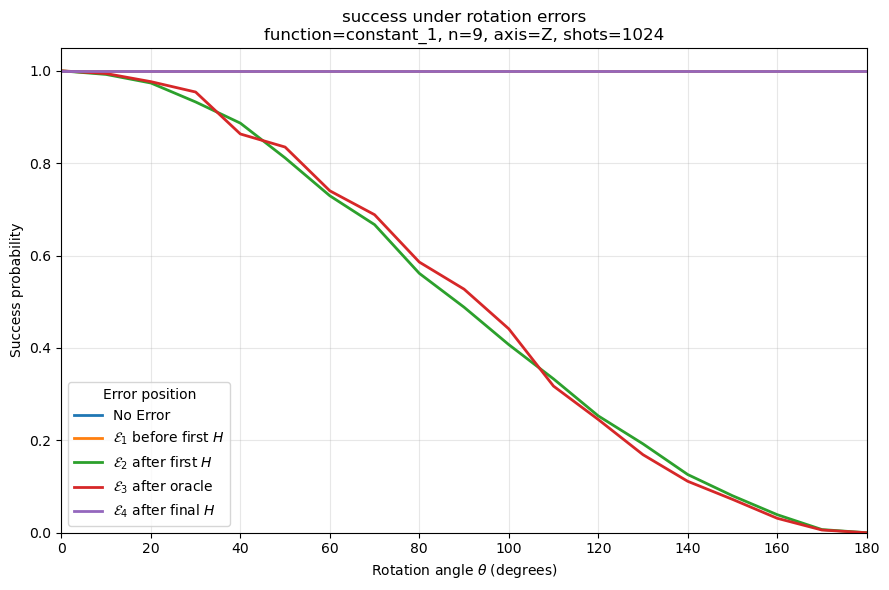

Saved figure: exp1_constant_1_n9_Z.pdf


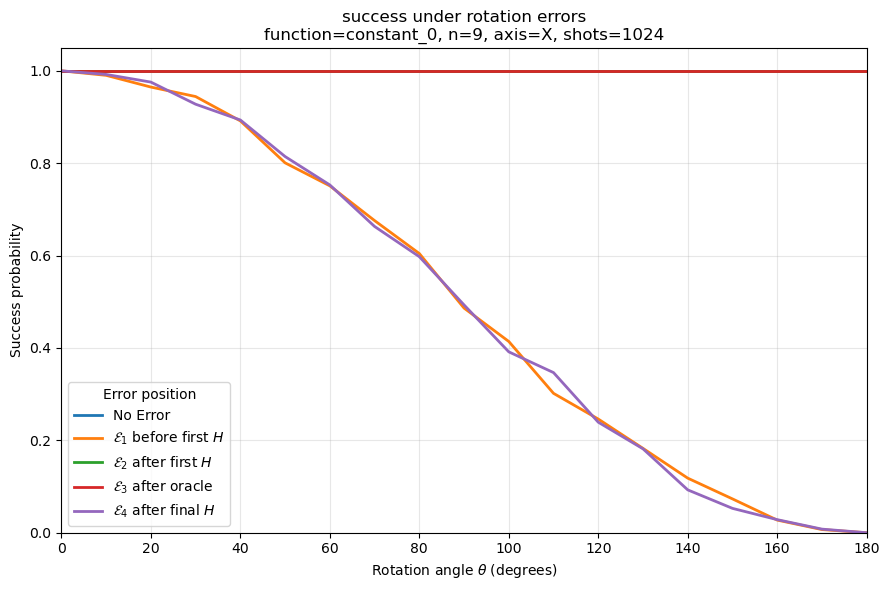

Saved figure: exp1_constant_0_n9_X.pdf


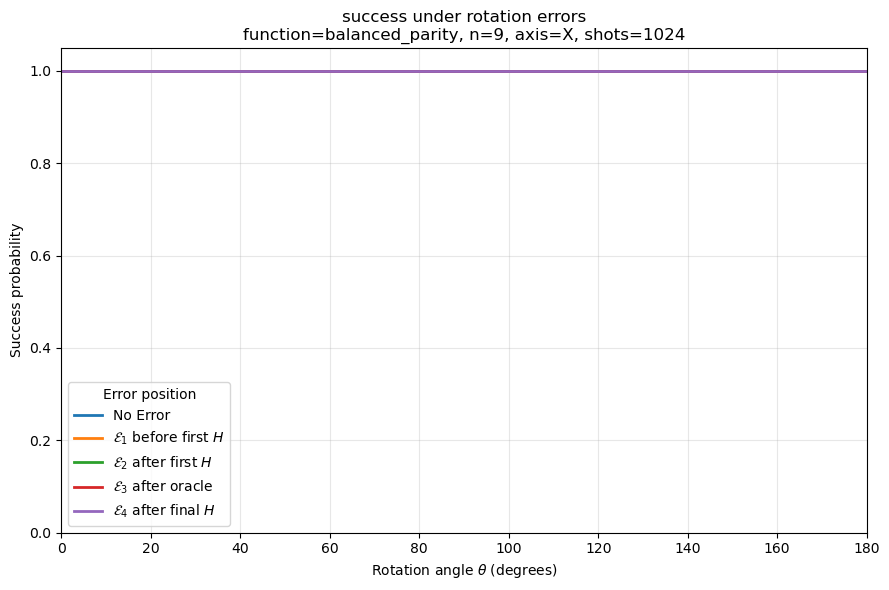

Saved figure: exp1_balanced_parity_n9_X.pdf


In [5]:
# Main report figures from Experiment 1
plot_error_positions(df_functions, n_plot=9, axis_plot="X", function_plot="constant_1")
plot_error_positions(df_functions, n_plot=9, axis_plot="Y", function_plot="constant_1")
plot_error_positions(df_functions, n_plot=9, axis_plot="Z", function_plot="constant_1")

plot_error_positions(df_functions, n_plot=9, axis_plot="X", function_plot="constant_0")
plot_error_positions(df_functions, n_plot=9, axis_plot="X", function_plot="balanced_parity")